Introduction

The main goal of this project is to analyze Drug Overdose Trends. Drug overdose deaths represent a critical public health crisis in the United States, with opioid-related fatalities reaching all time highs over the past decade. Especially for someone living in Seattle, I see many people openly using drugs on the streets, and the effects of such actions resulting in the “fentanyl bend”. My experience in Seattle and seeing how homelessness takes up such a large portion of the city motivated me to dive deep and find the cause and solutions that can be made to combat this ongoing drug overdose crisis. This project analyzes a comprehensive dataset of 20,249 drug overdose deaths in the state of Connecticut spanning from 2012 through 2017, and understand any patterns in overdose mortality to identify predictive factors that could inform targeted prevention strategies. 

Research Goals: 
The primary goal of this project is to uncover demographic, temporal, and geographic patterns in drug overdose deaths through developing predictive models that can identify high-risk profiles for fatal overdoses. By understanding which combinations of substances pose the greatest risk, which demographic groups are most vulnerable, and how overdose patterns have evolved over time, this analysis aims to provide data-driven insights for public health interventions and resource allocation. 

Research Questions: 
1. What demographic factors (age, sex, race) are most predictive of specific drug (heroin, fentanly, cocaine) involvement in fatal overdoses? 

2. How has the composition of drugs involved in overdose deaths changed over time, particularly regarding the emergence of fentanyl? 

3. Can we develop a classification model to predict whether an overdose will involve opioids based on demographic characteristics and other drug presence for early risk assessment to prevent death? 

4. Which Connecticut counties and regions have the highest overdose mortality rates, and do specific counties show distinct drug involvement patterns? 

In [4]:
#Exploratory Data Analysis 

#libraries loading
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import os

#reading csv
csv_path = os.path.join(os.path.expanduser("~"), "Desktop", "NEU", "Classes", "ALY_6140", "Capstone", "drug_deaths.csv")
drugs = pd.read_csv(csv_path)
drugs.head(10)
print(len(drugs))

# Check the columns we need
demographic_cols = ['Age', 'Sex', 'Race']
drug_cols = ['Heroin', 'Cocaine', 'Fentanyl']

print("\n===Null Values===")
print(drugs[demographic_cols + drug_cols].isnull().sum())

print("\n=== Data Types ===")
print(drugs[demographic_cols + drug_cols].dtypes)

5105

===Null Values===
Age          3
Sex          6
Race        13
Heroin       0
Cocaine      0
Fentanyl     0
dtype: int64

=== Data Types ===
Age         float64
Sex          object
Race         object
Heroin        int64
Cocaine       int64
Fentanyl     object
dtype: object


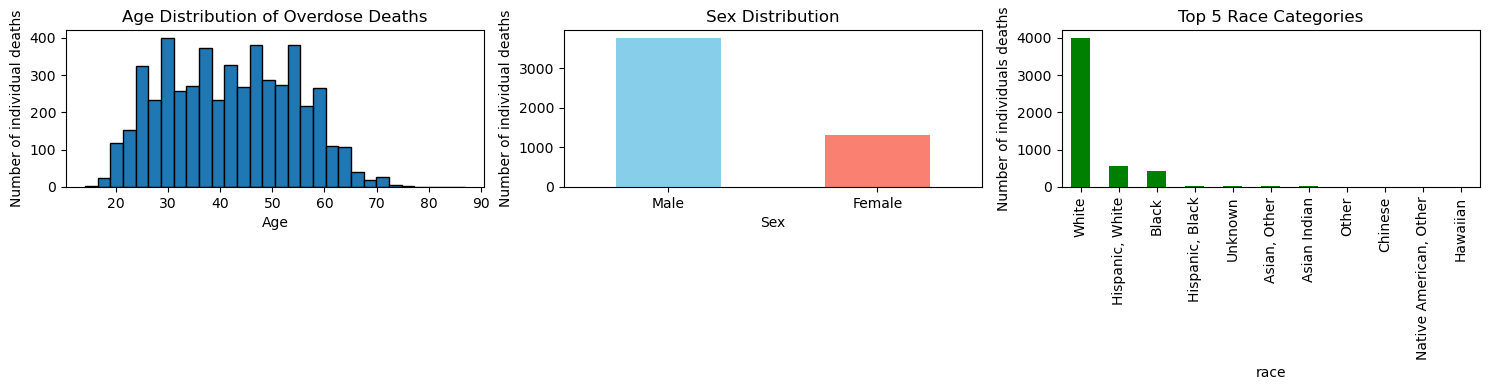

In [5]:
#Distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
drugs['Age'].dropna().plot(kind='hist', bins=30, ax=axes[0], edgecolor='black')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of individual deaths')
axes[0].set_title('Age Distribution of Overdose Deaths')

# Sex distribution
sex_known = drugs[drugs['Sex'].isin(['Male', 'Female'])]
sex_known['Sex'].value_counts().plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Number of individual deaths')
axes[1].set_title('Sex Distribution')
axes[1].tick_params(axis='x', rotation=0)

# Race distribution
drugs['Race'].value_counts().plot(kind='bar', ax=axes[2], color='green')
axes[2].set_xlabel('race')
axes[2].set_ylabel('Number of individuals deaths')
axes[2].set_title('Top 5 Race Categories')

plt.tight_layout()
plt.show()

Based on our distribution graph for age, we see that ages between 25 - 60 years old have a higher number of deaths in Conneticut from drug overdose. At the same time, there are almost triple the amount of males than females (as expected honestly), and most of these individuals are white, with a slight margin of hispanics and whites. This is good surface level data, but we need to consider some external factors: Conneticut is a white dominant state, as a result, most people there will be white; hence why the number of white individuals recorded from drug overdose is way higher than any other race. 


Heroin unique values:
Heroin
0    2576
1    2529
Name: count, dtype: int64

Cocaine unique values:
Cocaine
0    3584
1    1521
Name: count, dtype: int64

Fentanyl unique values:
Fentanyl
0           2873
1           2228
1-A            2
1 POPS         1
1 (PTCH)       1
Name: count, dtype: int64
=== Drug Involvement Rates ===
Heroin: 49.539666993143975% of cases
Cocaine: 29.794319294809014% of cases
Fentanyl: 43.721841332027424% of cases


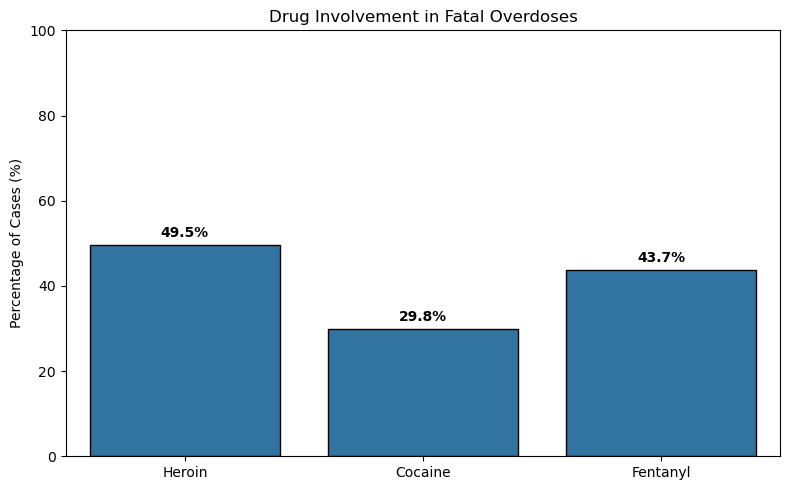

In [6]:
# Understanding the impact of each individual drug 
for drug in drug_cols:
    print(f"\n{drug} unique values:")
    print(drugs[drug].value_counts())

#Replacing Fentanyl Extras & Converting column into integers
drugs['Fentanyl']= drugs['Fentanyl'].replace({
    '1-A': 1,
    '1 POPS': 1,
    '1 (PTCH)': 1
})
drugs['Fentanyl'] = drugs['Fentanyl'].astype(int)

print("=== Drug Involvement Rates ===")
for drug_type in drug_cols:
    rate = drugs[drug_type].sum() / len(drugs) * 100
    print(f"{drug_type}: {rate}% of cases")

drug_rates = [drugs[drug_type].sum() / len(drugs) * 100 for drug_type in drug_cols]

#Plotting with seaborn
plt.figure(figsize=(8, 5))
ax = sns.barplot(x = drug_cols, y = drug_rates, edgecolor='black')
plt.ylabel('Percentage of Cases (%)')
plt.title('Drug Involvement in Fatal Overdoses')
plt.ylim(0, 100)
for i, v in enumerate(drug_rates):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Based on our analysis of individual drug impacts from heroin, cocaine, and fentanyl, we see that heroin and fentanyl are the top drug types that causes the most drug overdoses. This allows us to predict the drug type that has the highest impact on the total number of drug overdose deaths per year. The reason why the percentages do not add up to 100 is because there are overlapping cases where one individual overdosed from both types of drugs (having both types of drugs in their system when tested). 

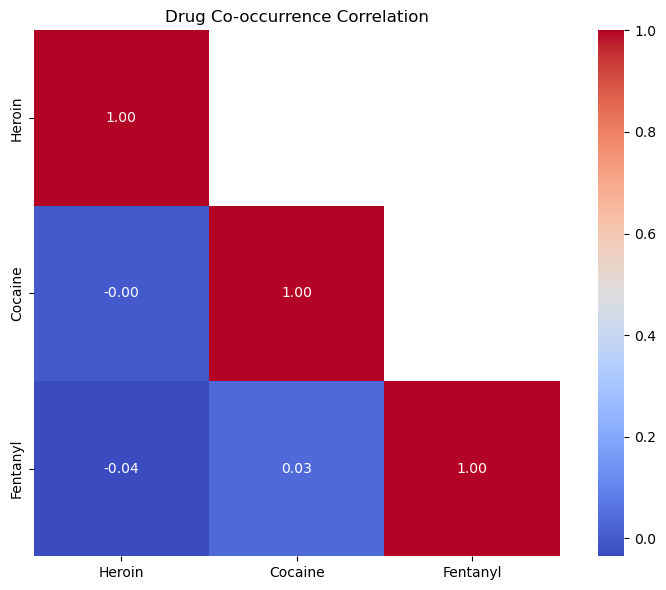

In [7]:
# Correlation between each drug type on a heatmap

drug_corr = drugs[drug_cols].corr()
mask = np.triu(np.ones_like(drug_corr, dtype=bool), k=1)

plt.figure(figsize=(8, 6))
sns.heatmap(drug_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, mask = mask)
plt.title('Drug Co-occurrence Correlation')
plt.tight_layout()
plt.show()

The heatmap above tells us how each drug type is correlated with each other. As we can see, ther is no correlation between heroine and cocaine, meaning every individual who overdosed did not test positive on both cocaine and heroin in their system. However, fentanyl and heroine have the strongest correlation between each other. Both drugs were identified as the most harmful and most risky drug type to cause overdose previously, as a result, this is not a surprise when heroin and fentanyl are used together, overdosing becomes more likely. Lastly, cocaine and fentanyl also has some type of correlation. This shows us that fentanyl is probably the most common and widely accessible drug for the public, and those who use other drugs will also have a higher chance of using fentanyl already. 

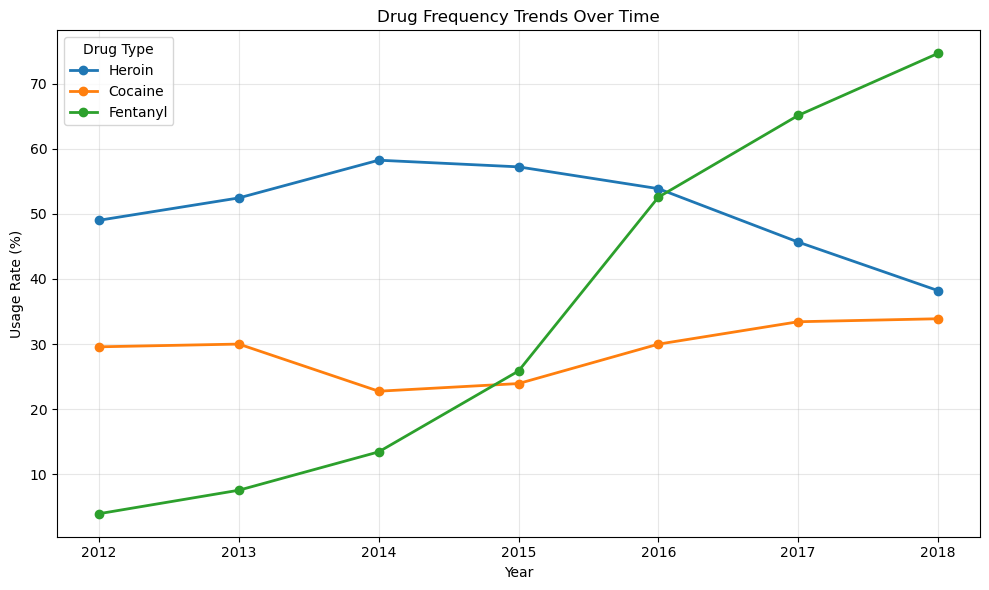


=== Drug Involvement by Year (%) ===

Heroin:
Year
2012.0    49.014085
2013.0    52.448980
2014.0    58.243728
2015.0    57.221458
2016.0    53.871320
2017.0    45.664740
2018.0    38.212181
Name: Heroin, dtype: float64

Cocaine:
Year
2012.0    29.577465
2013.0    30.000000
2014.0    22.759857
2015.0    23.933975
2016.0    29.989095
2017.0    33.429672
2018.0    33.889980
Name: Cocaine, dtype: float64

Fentanyl:
Year
2012.0     3.943662
2013.0     7.551020
2014.0    13.440860
2015.0    25.859697
2016.0    52.562704
2017.0    65.125241
2018.0    74.656189
Name: Fentanyl, dtype: float64


In [9]:
# Convert Date to datetime
drugs['Date'] = pd.to_datetime(drugs['Date'], format='mixed')
drugs['Year'] = drugs['Date'].dt.year

# Plot drug trends over years
fig, ax = plt.subplots(figsize=(10, 6))

for drug in drug_cols:
    yearly_rate = drugs.groupby('Year')[drug].mean() * 100
    ax.plot(yearly_rate, marker='o', label=drug, linewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('Usage Rate (%)')
ax.set_title('Drug Frequency Trends Over Time')
ax.legend(title = 'Drug Type')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Drug Involvement by Year (%) ===")
for drug in drug_cols:
    print(f"\n{drug}:")
    print(drugs.groupby('Year')[drug].mean() * 100)

Now we plot each drug type and the average use for each drug type per year. Based on the graph, we clearly see how fentanyl is definitely the most negative drug that has rapidly risen since 2012, with a steady slope increase in usage rate per year. Based on our Drug Involvement by Year (%) graph as well, we identify that 2018 had almost a 75% usage rate in fentanyl that caused drug overdose out of all the individuals recorded in the dataset, suggesting that fentanyl might be the drug type that is causing the most problems and overdose in Conneticut, but also overall in the United States. Cocaine has had a similar usage rate every year, not increasing or decreasing over time. Heroin on the other hand started off high in usage rates in 2012, but slightly dipped down closing in 2018. My prediction is that fentanyl has become one of the most widely accessible drugs, and also the cheapest. As a result, individuals who use drugs will always result in fentanyl first due to its low price and high accessibility. 

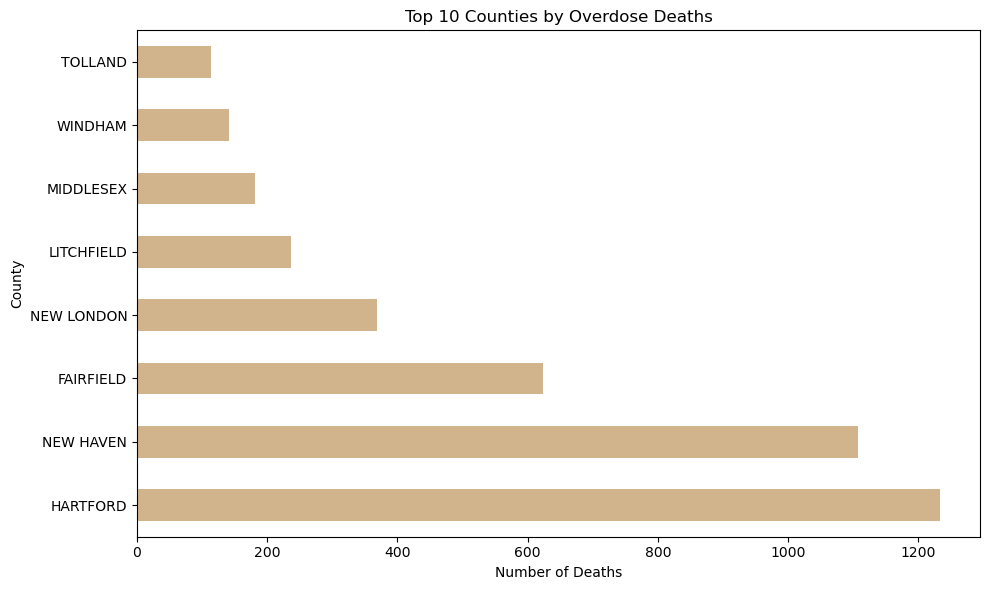


=== Drug Involvement in Top 5 Counties ===

HARTFORD (n=1233):
  Heroin: 44.0%
  Cocaine: 31.8%
  Fentanyl: 48.2%

NEW HAVEN (n=1107):
  Heroin: 51.6%
  Cocaine: 32.1%
  Fentanyl: 35.9%

FAIRFIELD (n=623):
  Heroin: 48.8%
  Cocaine: 30.7%
  Fentanyl: 43.8%

NEW LONDON (n=368):
  Heroin: 50.0%
  Cocaine: 24.5%
  Fentanyl: 39.7%

LITCHFIELD (n=237):
  Heroin: 58.2%
  Cocaine: 22.4%
  Fentanyl: 40.9%

MIDDLESEX (n=181):
  Heroin: 42.5%
  Cocaine: 28.7%
  Fentanyl: 43.6%

WINDHAM (n=142):
  Heroin: 52.1%
  Cocaine: 23.9%
  Fentanyl: 46.5%

TOLLAND (n=113):
  Heroin: 38.9%
  Cocaine: 25.7%
  Fentanyl: 51.3%


In [10]:
# Top counties with most overdose deaths
county_counts = drugs[drugs['DeathCounty'] != 'USA']['DeathCounty'].value_counts()

plt.figure(figsize=(10, 6))
county_counts.plot(kind='barh', color='tan')
plt.xlabel('Number of Deaths')
plt.ylabel('County')
plt.title('Top 10 Counties by Overdose Deaths')
plt.tight_layout()
plt.show()

# Specific drug type involvement by top counties
print("\n=== Drug Involvement in Top 5 Counties ===")
top_counties = drugs[drugs['DeathCounty'] != 'USA']['DeathCounty'].value_counts().index

for county in top_counties:
    county_data = drugs[drugs['DeathCounty'] == county]
    print(f"\n{county} (n={len(county_data)}):")
    for drug in drug_cols:
        rate = county_data[drug].mean() * 100
        print(f"  {drug}: {rate:.1f}%")

Lastly, we are able to identify the top 8 counties in Conneticut that experiences the highest drug overdose rates. The graph shows that the county Hartford has the most amount of drug overdoses between 2012-2018, followed by New Havben then Fairfield. The county that has the least average amount of deaths from drug overdose is Tolland. Below the graph, we have the specific drug type associated with each county. Cocaine has the lowest overdose rate in every single county in Conneticut, further proving our previous analysis on the frequency of each drug type. As a result, fentanyl and heroin have the highest number of overdose rates for each county. 

In [12]:
#Predictive Model: Random Forest Prediction on Fentanyl 
#Data Cleaning, Processing, and Wrangling

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
f = drugs['Fentanyl'].copy() #1 = fentanyl present, 2 = fentanyl not present 
features = ['Age', 'Sex', 'Race', 'DeathCounty', 'Year', 'Heroin', 'Cocaine']
feat = drugs[features].copy()

print("=== Target Variable (y) ===")
print(f.value_counts())
print(f"\nClass distribution:")
print(f.value_counts(normalize=True) * 100)

print("\n=== Features Info ===")
feat.info()
print(feat.head())


print("=== Missing Values in Features ===")
missing_df = feat.isnull().sum().reset_index()
missing_df.columns = ['Feature', 'Missing Count']
print(missing_df[missing_df['Missing Count'] > 0])

print(f"\n=== Missing in Target (Fentanyl) ===")
print(f"Missing count: {f.isnull().sum()}")

print("=== Encoding Categorical Variables ===")
#Encoding categorical columns into binary 
categorical_cols = ['Sex', 'Race', 'DeathCounty']

# Check unique values before encoding
print("\nUnique values before encoding:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Number of unique values: {feat[col].nunique()}")
    print(f"  Sample values: {feat[col].unique()[:5]}")

# Use One-Hot Encoding for all categorical variables
feat = pd.get_dummies(feat, columns=categorical_cols, drop_first=True)

print("\nOne-Hot Encoding complete:")
for col in categorical_cols:
    encoded_cols = [c for c in feat.columns if c.startswith(col + '_')]
    print(f"\n✅ {col} encoded into {len(encoded_cols)} binary columns:")
    print(f"   Columns: {encoded_cols}")
    
print("\n" + "="*50)
print("=== Encoding Complete ===")
print(f"Features after encoding: {list(feat.columns)}")
print(f"Shape: {feat.shape}")

print("\n=== Final Data Types ===")
print(feat.dtypes)

print("\n=== First 5 Rows After Encoding ===")
print(feat.head())

=== Target Variable (y) ===
Fentanyl
0    2873
1    2232
Name: count, dtype: int64

Class distribution:
Fentanyl
0    56.278159
1    43.721841
Name: proportion, dtype: float64

=== Features Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5105 entries, 0 to 5104
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          5102 non-null   float64
 1   Sex          5099 non-null   object 
 2   Race         5092 non-null   object 
 3   DeathCounty  4005 non-null   object 
 4   Year         5103 non-null   float64
 5   Heroin       5105 non-null   int64  
 6   Cocaine      5105 non-null   int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 279.3+ KB
    Age     Sex          Race DeathCounty    Year  Heroin  Cocaine
0   NaN     NaN           NaN         NaN  2014.0       0        0
1  48.0    Male         Black   FAIRFIELD  2013.0       0        1
2  30.0  Female         White         NaN  2016.0   

In [15]:
#Predictive Model: Building the model 

print("=== Train/Test Split ===")

# (80% train, 20% test)
# Use stratify to maintain class balance in both sets
f_train, f_test, feat_train, feat_test = train_test_split(
    f, feat,
    test_size=0.2, 
    random_state=42, 
    stratify=f  # Ensures balanced fentanyl distribution in both sets
)

print(f"\nTraining set: {len(f_train)} samples ({len(f_train)/len(f)*100:.1f}%)")
print(f"Test set: {len(f_test)} samples ({len(f_test)/len(f)*100:.1f}%)")

print("\n=== Fentanyl Distribution in Training Set ===")
print(f_train.value_counts())

print("\n=== Fentanyl Distribution in Test Set ===")
print(f_test.value_counts())

print("=== Training Random Forest Model ===")
# Create Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    random_state=42,       # For reproducibility
    max_depth=10,          # Maximum depth of each tree
    min_samples_split=10,  # Minimum samples required to split a node
    class_weight='balanced'  # Handle class imbalance
)

# Train the model
rf_model.fit(feat_train, f_train)

# Make predictions on test set
f_pred = rf_model.predict(feat_test)

# Get prediction probabilities (useful for ROC curve later)
f_pred_proba = rf_model.predict_proba(feat_test)[:, 1]  # Probability of class 1 (Fentanyl=1)

# Quick preview of predictions
print("\n=== Prediction Preview ===")
print(f"First 10 actual values:    {f_test.values[:10]}")
print(f"First 10 predicted values: {f_pred[:10]}")

# Check prediction distribution
print("\n=== Prediction Distribution ===")
unique, counts = np.unique(f_pred, return_counts=True)
for val, count in zip(unique, counts):
    print(f"Predicted {val}: {count} samples ({count/len(f_pred)*100:.1f}%)")


print("=== Model Performance Evaluation ===\n")
# Calculate performance metrics
accuracy = accuracy_score(f_test, f_pred) #correct predictions/all predictions
precision = precision_score(f_test, f_pred) #true positives/all positives
recall = recall_score(f_test, f_pred) #Of all actual Fentanyl cases, how many did we catch?
f1 = f1_score(f_test, f_pred) #balance between precision and recall 
roc_auc = roc_auc_score(f_test, f_pred_proba)

# Display metrics
print("Performance & Accuracy Metrics:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"  ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")

# Detailed classification report
print("\n=== Detailed Classification Report ===")
print(classification_report(f_test, f_pred, target_names=['No Fentanyl (0)', 'Fentanyl (1)']))

# Confusion matrix
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(f_test, f_pred)
print(cm)

print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {cm[0,0]} - Correctly predicted NO fentanyl")
print(f"  False Positives (FP): {cm[0,1]} - Incorrectly predicted fentanyl")
print(f"  False Negatives (FN): {cm[1,0]} - Missed fentanyl cases")
print(f"  True Positives (TP):  {cm[1,1]} - Correctly predicted fentanyl")

=== Train/Test Split ===

Training set: 4084 samples (80.0%)
Test set: 1021 samples (20.0%)

=== Fentanyl Distribution in Training Set ===
Fentanyl
0    2298
1    1786
Name: count, dtype: int64

=== Fentanyl Distribution in Test Set ===
Fentanyl
0    575
1    446
Name: count, dtype: int64
=== Training Random Forest Model ===

=== Prediction Preview ===
First 10 actual values:    [1 1 1 1 0 1 0 0 0 0]
First 10 predicted values: [1 1 1 1 0 1 0 0 0 0]

=== Prediction Distribution ===
Predicted 0: 500 samples (49.0%)
Predicted 1: 521 samples (51.0%)
=== Model Performance Evaluation ===

Performance & Accuracy Metrics:
  Accuracy:  0.7561 (75.61%)
  Precision: 0.6891 (68.91%)
  Recall:    0.8049 (80.49%)
  F1-Score:  0.7425 (74.25%)
  ROC-AUC:   0.8236 (82.36%)

=== Detailed Classification Report ===
                 precision    recall  f1-score   support

No Fentanyl (0)       0.83      0.72      0.77       575
   Fentanyl (1)       0.69      0.80      0.74       446

       accuracy     

=== Creating Performance Visualizations ===



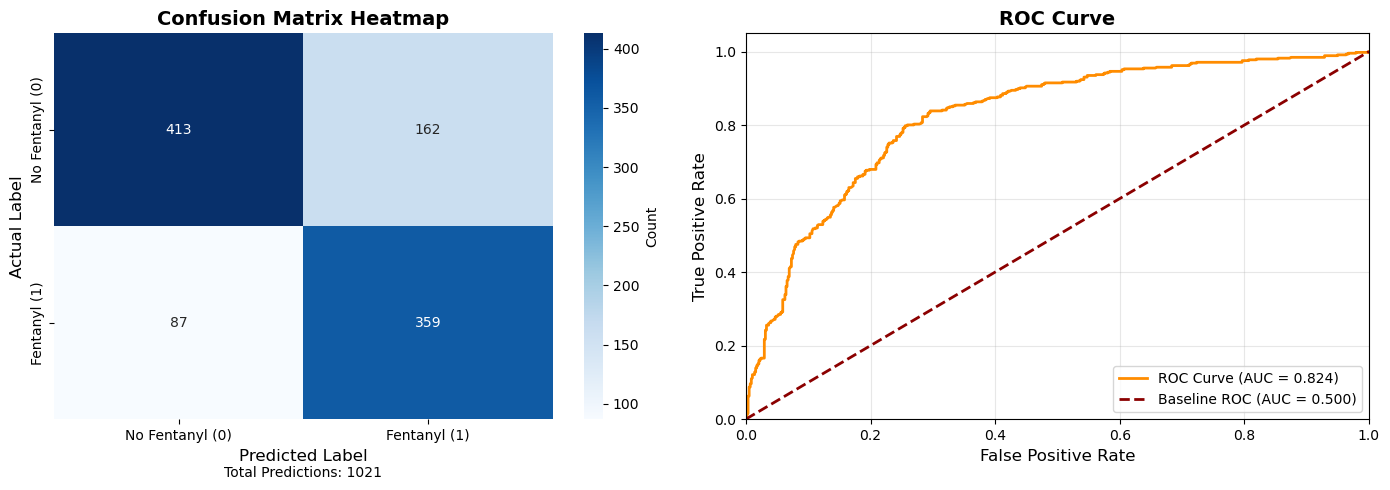

In [16]:
#Predictive Model Last Step: Visualizing Results & Understanding Data 
print("=== Creating Performance Visualizations ===\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Subplot 1: Confusion Matrix Heatmap With Seaborn 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fentanyl (0)', 'Fentanyl (1)'],
            yticklabels=['No Fentanyl (0)', 'Fentanyl (1)'],
            cbar_kws={'label': 'Count'},
            ax=axes[0])

axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
# Add text annotations for clarity
total = cm.sum()
axes[0].text(0.5, -0.15, f'Total Predictions: {total}', 
             ha='center', transform=axes[0].transAxes, fontsize=10)

#Subplot 2: ROC Curve 
fpr, tpr, thresholds = roc_curve(f_test, f_pred_proba)
roc_auc = roc_auc_score(f_test, f_pred_proba)

# Plot ROC curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2,label=f'ROC Curve (AUC = {roc_auc:.3f})')
# Plot diagonal reference line (random classifier)
axes[1].plot([0, 1], [0, 1], color='darkred', lw=2, linestyle='--', label='Baseline ROC (AUC = 0.500)')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Feature Importance Analysis ===

Feature Importance Scores:
                    Feature  Importance
                       Year    0.654487
                        Age    0.158643
                     Heroin    0.034999
                   Sex_Male    0.032825
                    Cocaine    0.018781
       DeathCounty_HARTFORD    0.015560
      DeathCounty_NEW HAVEN    0.014611
                 Race_White    0.011023
       Race_Hispanic, White    0.009883
                 Race_Black    0.008427
     DeathCounty_NEW LONDON    0.007227
        DeathCounty_TOLLAND    0.006017
     DeathCounty_LITCHFIELD    0.005677
        DeathCounty_WINDHAM    0.005244
      DeathCounty_MIDDLESEX    0.004504
       Race_Hispanic, Black    0.003311
               Race_Unknown    0.002724
          Race_Asian, Other    0.002640
                 Race_Other    0.001966
               Race_Chinese    0.000652
              Race_Hawaiian    0.000442
                Sex_Unknown    0.000356
            Deat

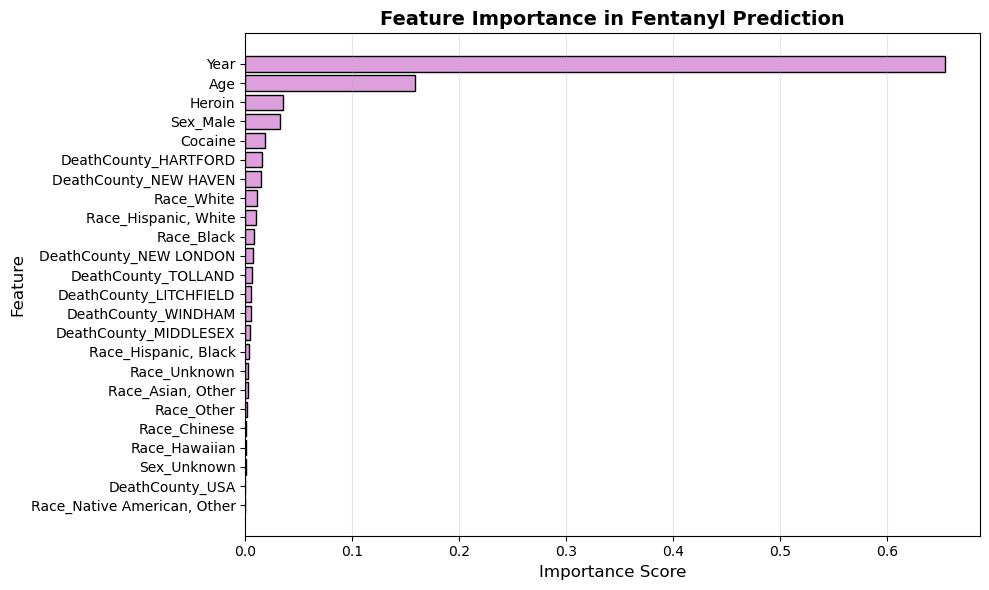

In [17]:
#Analysis on Random Forest Distinctive Feature Used to Predict Our Outcome 
print("=== Feature Importance Analysis ===\n")

# Get feature importances from the trained model
feature_importance = rf_model.feature_importances_
feature_names = feat_train.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Matrix table for importance scores
print("Feature Importance Scores:")
print(importance_df.to_string(index=False))
importance_df['Importance'] = (importance_df['Importance'] / importance_df['Importance'].sum())

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='plum', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance in Fentanyl Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Interpretations & Conclusion:

In conclusion, my analysis successfully demonstrated that fentanyl involvement in Connecticut overdose deaths can be predicted with high accuracy using a Random Forest classification model based on demographic, temporal, and drug interaction features. My model achieved high accuracy in identifying high-risk cases. Feature importance revealed that age and year were the dominant predictors, confirming the dramatic emergence of fentanyl over the past couple of years. My findings suggest that intervention strategies should prioritize Fentanyl & Heroin users and target specific age groups and geographic hotspots identified through the model to combat this crisis. The presence of false negatives and false positives highlights the need for continued model refinement and other harm reduction approaches/features, including widespread fentanyl testing strip distribution particularly in high-risk counties.

References:

Drug overdose deaths. (n.d.). www.kaggle.com. https://www.kaggle.com/datasets/ruchi798/drug-overdose-deaths